In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import math
import os
import matplotlib.pyplot as plt

import pathlib
import joblib
from joblib import Parallel, delayed
import contextlib
from tqdm import tqdm

import pyarrow as pa
import pyarrow.parquet as pq

from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, gaussian,  threshold_minimum, threshold_local
from skimage.segmentation import clear_border, expand_labels, find_boundaries, watershed, expand_labels, mark_boundaries
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation, erosion, ball, thin, skeletonize, opening
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from skimage import exposure, measure, util
from skimage.transform import rescale

import napari

from tifffile import imread
import tifffile

import warnings
warnings.filterwarnings("ignore")

In [ ]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [1]:
def pixel_size(tif_path):
    """
    Extracts the pixel size (spacing) in microns from a TIFF image.

    This function reads TIFF metadata to determine the pixel spacing in the x, y, and z 
    dimensions, returning them as a list.

    Parameters:
    -----------
    tif_path : str
        Path to the TIFF file.

    Returns:
    --------
    original_spacing : list of float
        A list containing the pixel sizes in microns: [x_pixel_size_um, y_pixel_size_um, z_pixel_size_um].

    Notes:
    ------
    - The x and y resolutions are extracted from the TIFF XResolution and YResolution tags.
    - The z-spacing is inferred from the `IJMetadata` tag if available; otherwise, it falls back to 
      the `ImageDescription` tag.
    - Assumes the metadata is formatted in a way compatible with ImageJ or similar software.
    """
    with tifffile.TiffFile(tif_path) as tif:
        tif_tags = {}
        for tag in tif.pages[0].tags.values():
            name, value = tag.name, tag.value
            tif_tags[name] = value

        x_pixel_size_um = 1/((tif_tags["XResolution"])[0]/(tif_tags["XResolution"][1]))
        y_pixel_size_um = 1/((tif_tags["YResolution"])[0]/(tif_tags["YResolution"][1]))
        try:
            z_pixel_size_um = float(str(tif_tags["IJMetadata"]).split("nscales=")[1].split(",")[2].split("\\nunit")[0])
        except:
            z_pixel_size_um = (float(str(tif_tags["ImageDescription"]).split("spacing=")[1].split("loop")[0]))
       
    original_spacing = [x_pixel_size_um,y_pixel_size_um,z_pixel_size_um]
    return original_spacing

In [ ]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Converts an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.

    Notes:
    ------
    - This function performs a linear transformation to scale pixel values.
    - It ensures that the output values are properly mapped between `target_type_min` and 
      `target_type_max`.
    """
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [5]:
def add_image_details(df, filename, flag):
    """
    Adds experimental details extracted from the filename to a dataframe.

    This function parses the filename to infer experimental details such as 
    well number, imaging day, mechanical stiffness condition, and treatment type.
    The extracted details are appended as new columns to the dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to which image metadata will be added.
    filename : str
        The filename of the image, used to extract experimental details.
    flag : str
        A flag indicating any segmentation issues detected during processing.

    Returns:
    --------
    df : pandas.DataFrame
        The updated dataframe with the following added columns:
        - 'filename': The original filename.
        - 'flag': Segmentation flag indicating potential issues.
        - 'well': The well number (1 or 2) inferred from the filename.
        - 'day': The experimental time point (0, 1, 3, or 7 days).
        - 'condition': The mechanical stiffness condition ('soft', 'stiff', or 'blank').
        - 'treatment': The treatment applied ('blebbistatin', 'ROCKi', 'batimastat', 'ABT737', or 'none').
        - 'image_type': A combined descriptor of the condition and day (e.g., 'soft, d3').
    """
    df["filename"] = filename
    df["flag"] = flag
    if ("well1" in filename):
        df["well"] = 1
    else:
        df["well"] = 2
    # Day #        
    if "d0" in filename:
        df["day"] =  0
    elif "d1" in filename:
        df["day"] =  1
    elif "d3" in filename:
        df["day"] =  3
    else:
        df["day"] =  7
    # Stiffness
    if 'soft' in filename:
        df["condition"] =  'soft'
    elif 'stiff' in filename:
        df["condition"] =  'stiff'
    else:
        df["condition"] =  'blank'
    if "bleb" in filename.lower():
        df["treatment"] = "blebbistatin"
    elif "rock" in filename.lower():
        df["treatment"] = "ROCKi"
    elif ("batimastat" in filename.lower()) or "mmpi" in filename.lower():
        df["treatment"] = "batimastat"
    elif "abt" in filename.lower():
        df["treatment"] = "ABT737"
    else:
        df["treatment"] = "none"
    df['image_type'] = df["condition"].astype(str) + ", d" + df["day"].astype(str)
    return df

In [4]:
def segment_and_quantify(i, image_paths, membrane_paths, nuclei_paths, mito_paths, scale_value=0.25, to_plot=True, membrane_channel= 2, dapi_channel = 0, mito_channel=1):
    filename = os.path.basename(image_paths[i]).replace("_", "").lower()
    try: #try/except just lets you carry on segmenting the other images even if there's an issue with one
        # it's helpful in case one fails and you're running it overnight, the others should still do their thing!
    ##############RESCALE IMAGES
        flag = "None"
        ###### SORT OUT THE GRAYSCALE IMAGES SO YOU CAN VIEW AT THE END
        multi_channel_image = convert(imread(image_paths[i]), 0,255, np.uint8)

        caax_image = multi_channel_image[:,membrane_channel,:,:]
        dapi_image = multi_channel_image[:,dapi_channel,:,:]
        mito_image = multi_channel_image[:,mito_channel,:,:]  
        original_spacing = pixel_size(image_paths[i])
        scale_change = original_spacing[2] / original_spacing[0] #how much bigger the z step is than x,y
        new_pixel_size = (1/scale_value) * original_spacing[0]
        rescaled_caax_image = rescale(scale = (scale_value*scale_change, scale_value, scale_value), image=(caax_image ), anti_aliasing = False)
        rescaled_dapi_image = rescale(scale = (scale_value*scale_change, scale_value, scale_value), image=(dapi_image ), anti_aliasing = False)
        rescaled_mito_image = rescale(scale = (scale_value*scale_change, scale_value, scale_value), image=(mito_image), anti_aliasing = False)
        rescaled_acinus_image = rescaled_caax_image + rescaled_dapi_image
        rgb_image = np.stack([rescaled_mito_image, rescaled_caax_image, rescaled_dapi_image], axis=-1)


        ###### SORT OUT THE MASKS SO YOU CAN VIEW AT THE END
        mito_mask = imread(mito_paths[i])
        dapi_mask = imread(nuclei_paths[i])
        membrane_mask = imread(membrane_paths[i])

        rescaled_mito_mask = rescale(scale = (scale_value*scale_change, scale_value, scale_value), image = mito_mask, anti_aliasing= False) # can change this to 1 if you want the most detail (slow!!)
        rescaled_dapi_mask = rescale(scale = (0.25*scale_change, 0.25, 0.25), image = dapi_mask, anti_aliasing= False)
        rescaled_membrane_mask = rescale(scale = (0.25*scale_change, 0.25, 0.25), image = membrane_mask, anti_aliasing= False)


        clipped = rescaled_acinus_image.clip(min =np.quantile(rescaled_acinus_image, 0.1), max = np.quantile(rescaled_acinus_image, 0.85))
        acinus_smoothed = gaussian(clipped, sigma = 4)
        thresh = threshold_otsu(acinus_smoothed)
        binary = acinus_smoothed > thresh
        binary = remove_small_holes(binary, area_threshold = 100000)
        binary = remove_small_objects(binary, min_size = 10000)
        labelled_image = label(binary)
        table = regionprops_table(labelled_image, properties=('label', "area"),) #only keep largest acinus
        condition = (table['area'] >= (table["area"]).max())
        input_labels = table['label']
        output_labels = input_labels * condition
        filtered_labelled_acinus = util.map_array(labelled_image, input_labels, output_labels)
        table = regionprops_table(filtered_labelled_acinus, properties=('label', 'inertia_tensor_eigvals'),) #test sphericity of largest identified acinus
        condition = table['inertia_tensor_eigvals-2']/table['inertia_tensor_eigvals-0'] >= (0.55)
        if condition == False:
            flag = "multiple_acini_split"
            acinus_smoothed = gaussian(clipped, sigma = 1)
            thresh = threshold_otsu(acinus_smoothed)
            binary = acinus_smoothed > thresh
            binary = remove_small_holes(binary, area_threshold = 100000)
            binary = remove_small_objects(binary, min_size = 10000)
            binary = erosion(binary, ball(8))
            labelled_image = label(binary)
            table = regionprops_table(labelled_image, properties=('label', "area"),)
            condition = (table['area'] >= (table["area"]).max())
            input_labels = table['label']
            output_labels = input_labels * condition
            filtered_labelled_acinus = util.map_array(labelled_image, input_labels, output_labels)
            filtered_labelled_acinus = expand_labels(filtered_labelled_acinus, distance=8)
        cleaned_acinus_mask = filtered_labelled_acinus * (filtered_labelled_acinus>0)
         ####################################################################################################################################
        rescaled_membrane_mask = rescaled_membrane_mask * cleaned_acinus_mask
        rescaled_dapi_mask = rescaled_dapi_mask * cleaned_acinus_mask
        ####################PROCESS THE MEMBRANE TO THIN AND CLEAN####################
        cleaned_membrane_mask = gaussian(rescaled_membrane_mask, sigma = 0.5) # Apply some smoothing to fill any gaps
        thresh = threshold_otsu(cleaned_membrane_mask)
        cleaned_membrane_mask = cleaned_membrane_mask > thresh

        cleaned_thinned_membrane_mask = thin(cleaned_membrane_mask[0,:,:], max_num_iter=4)
        for i in range(1, rescaled_membrane_mask.shape[0]):
            thinned = thin(rescaled_membrane_mask[i,:,:], max_num_iter=4)
            cleaned_thinned_membrane_mask = np.dstack((cleaned_thinned_membrane_mask, thinned))
        cleaned_thinned_membrane_mask = np.rollaxis(cleaned_thinned_membrane_mask, 2,0)
        cleaned_thinned_membrane_mask = remove_small_objects(cleaned_thinned_membrane_mask, min_size = 40)
        #####################CLEAN UP THE NUCLEI####################
        cleaned_dapi_mask = rescaled_dapi_mask * (util.invert(cleaned_thinned_membrane_mask)) # Don't allow nuclei to overlap membrane
        cleaned_dapi_mask = rescaled_dapi_mask
        cleaned_dapi_mask = gaussian(cleaned_dapi_mask, 0.8)
        thresh = threshold_otsu(cleaned_dapi_mask)
        cleaned_dapi_mask = cleaned_dapi_mask > thresh
        distances = ndi.distance_transform_edt(erosion(cleaned_dapi_mask, ball(3)))
        nuclear_size_in_pixels = 4/new_pixel_size
        coordinates = peak_local_max(distances, min_distance = int(nuclear_size_in_pixels)) ####seed points at least 4um apart
        marker_locations = coordinates.data

        markers = np.zeros(cleaned_dapi_mask.shape, dtype=np.uint32)
        marker_indices = tuple(np.round(marker_locations).astype(int).T)
        markers[marker_indices] = np.arange(len(marker_locations)) + 1
        markers_big = dilation(markers, ball(2))
        segmented = watershed(-distances, markers_big, mask=cleaned_dapi_mask)
        segmented = clear_border(segmented)
        ## Filter out small nuclei
        table = regionprops_table(segmented, properties=('label', 'area'),)
        volume_threshold = (4/3)*np.pi * (2/new_pixel_size)**3     # radius 2um nucleus
        condition = (table['area'] >= volume_threshold)
        input_labels = table['label']
        output_labels = input_labels * condition
        watershed_dapi = util.map_array(segmented, input_labels, output_labels)
        #############WATERSHED OF MEMBRANE BASED ON NUCLEI POSITIONS
        zvalues = regionprops_table(watershed_dapi, properties =( "label", "centroid"))["centroid-0"]
        xvalues = regionprops_table(watershed_dapi, properties =( "label", "centroid"))["centroid-1"]
        yvalues = regionprops_table(watershed_dapi, properties =( "label", "centroid"))["centroid-2"]
        coordinates = np.stack((zvalues, xvalues, yvalues), axis=0).T.astype(int)
        distances = ndi.distance_transform_edt(util.invert(cleaned_membrane_mask))
        marker_locations = coordinates.data
        markers = np.zeros(cleaned_membrane_mask.shape, dtype=np.uint32)
        marker_indices = tuple(np.round(marker_locations).astype(int).T)
        markers[marker_indices] = np.arange(len(marker_locations)) + 1
        markers_big = dilation(markers, ball(2))
        segmented = watershed(-distances, markers_big, mask=util.invert(cleaned_membrane_mask))
        segmented = clear_border(segmented)
        ## Filter out small values
        table = regionprops_table(segmented, properties=('label', 'area'),)
        condition = (table['area'] >= volume_threshold) #########cell volume has same cut off as nuclei
        input_labels = table['label']
        output_labels = input_labels * condition

        watershed_membrane = util.map_array(segmented, input_labels, output_labels)
        watershed_membrane_expanded = expand_labels(watershed_membrane, distance = 12)
        watershed_membrane_expanded = watershed_membrane_expanded * cleaned_acinus_mask

        mito_labels = label(rescaled_mito_mask)

        matching_nuc_and_cell = find_matching_properties(watershed_dapi, watershed_membrane_expanded, new_pixel_size, filename)
        #########ANALYSIS
        table = pd.DataFrame(regionprops_table(watershed_membrane_expanded, properties=('label', 'area'),))
        mito_props_table = pd.DataFrame(regionprops_table(mito_labels,properties=('label', 'area')))
        nuclei_props_table = pd.DataFrame(regionprops_table(watershed_dapi,properties=('label', 'area')))
        acinus_props_table = pd.DataFrame(regionprops_table(cleaned_acinus_mask,properties=('label', 'area')))

        cell_labels= []
        n_mito = []
        mito_vols = []
        all_distances = []

        for i in matching_nuc_and_cell["cell_label"].unique():
            cell_index = i
            try:
                nuc_index = int(matching_nuc_and_cell.loc[matching_nuc_and_cell['cell_label'] == cell_index]["nucleus_label"])
            except:
                print(cell_index, matching_nuc_and_cell.loc[matching_nuc_and_cell['cell_label'] == cell_index]["nucleus_label"])
            mito_in_region = np.unique(mito_labels * (watershed_dapi == nuc_index))
            number_of_mito = len(mito_in_region)
            total_mito_vol = mito_props_table[mito_props_table["label"].isin(mito_in_region)]["area"].sum()* new_pixel_size**3
            cell_labels.append(cell_index)
            mito_vols.append(total_mito_vol)
            n_mito.append(number_of_mito)

            ####MITO INTENSITY WITH DISTANCE
            nuc_of_interest = watershed_dapi * (watershed_dapi == nuc_index) > threshold_otsu(watershed_dapi * (watershed_dapi == nuc_index))
            cell_of_interest = watershed_membrane_expanded * (watershed_membrane_expanded == cell_index) > threshold_otsu(watershed_membrane_expanded * (watershed_membrane_expanded == cell_index))
            distance = ((distance_transform_edt(1- (nuc_of_interest))) * cell_of_interest) * (new_pixel_size*new_pixel_size)
            mito_in_cell = cell_of_interest * (mito_labels > 1)

            count_with_distance = pd.DataFrame(zip(np.ravel(distance), np.ravel(mito_in_cell)), columns=['Distance', 'Mito_in_cell'])   
            count_with_distance['Rounded_Distance'] = count_with_distance.Distance.apply(lambda x: round(x, 2))
            count_with_distance = count_with_distance.groupby('Rounded_Distance').Mito_in_cell.agg(['sum', 'count']).reset_index()
            # count_with_distance = count_with_distance.rename(columns={'sum': 'Sum_of_mito_pixels', 'count': 'number_of_pixels'})
            count_with_distance["Cell Label"] = cell_index
            count_with_distance = add_image_details(count_with_distance, filename)

            all_distances.append(count_with_distance)
            #all_distances["image"] = "".join(ch for ch in(os.path.basename(nucleus_path)) if ch.isalnum()).split("segmentation")
        n_mito_df = pd.DataFrame(
        {'cell_label': cell_labels,
            'number_of_mito': n_mito,
            "vol_of_mito_um": mito_vols
        })
        all_distance_df = pd.concat(all_distances)
        matching_nuc_and_cell = matching_nuc_and_cell.merge(n_mito_df)
        acinus_volume = acinus_props_table["area"][0]* new_pixel_size**3
        matching_nuc_and_cell["total_acinus_volume"]= acinus_volume

        matching_nuc_and_cell["mito/cell_vol"] = matching_nuc_and_cell["vol_of_mito_um"]/matching_nuc_and_cell["cell_volume_um"]
        matching_nuc_and_cell= matching_nuc_and_cell[(matching_nuc_and_cell["mito/cell_vol"]< 0.5) & (matching_nuc_and_cell["nucleus/cell_volume"]< 0.9) & (matching_nuc_and_cell["vol_of_mito_um"]>0)]
        matching_nuc_and_cell["total_nuclear_volume_um"] = sum(matching_nuc_and_cell["nucleus_volume_um"])
        matching_nuc_and_cell["total_mito_volume_um"] = sum(matching_nuc_and_cell["vol_of_mito_um"])
        matching_nuc_and_cell["number_of_cells"] = matching_nuc_and_cell.shape[0]
        matching_nuc_and_cell=add_image_details(matching_nuc_and_cell, filename)

        matching_nuc_and_cell.to_parquet("E:\\FABIANNA\\mito_volumes_10A_{}.parquet".format(filename))
        all_distance_df.to_parquet("E:\\FABIANNA\\mito_distances_10A_{}.parquet".format(filename))
    except:
        print("filename {} FAILED".format(filename))

In [6]:
def find_matching_properties(labelled_nucleus, labelled_cell, new_pixel_size, filename):
    matching_nuc_and_cell = []
    for region in (regionprops(labelled_nucleus)):
        x,y,z = int(region.centroid[1]), int(region.centroid[2]), int(region.centroid[0])
        matching_nuc_and_cell.append([region.label, labelled_cell[z,x,y]])
    matching_nuc_and_cell = pd.DataFrame(matching_nuc_and_cell, columns=['nucleus_label', 'cell_label'])
    cell_props = pd.DataFrame(regionprops_table(labelled_cell, properties = ("label", "area")))\
        .rename(columns={'label': 'cell_label', 'area': 'cell_volume'})
    nuclear_props = pd.DataFrame(regionprops_table(labelled_nucleus, properties = ("label", "area")))\
        .rename(columns={'label': 'nucleus_label', 'area': 'nucleus_volume'})
    matching_nuc_and_cell = matching_nuc_and_cell.merge(cell_props).merge(nuclear_props)
    matching_nuc_and_cell["nucleus/cell_volume"] = matching_nuc_and_cell["nucleus_volume"]/matching_nuc_and_cell["cell_volume"]
    matching_nuc_and_cell["nucleus_volume_um"] = matching_nuc_and_cell["nucleus_volume"] * new_pixel_size**3
    matching_nuc_and_cell["cell_volume_um"] = matching_nuc_and_cell["cell_volume"] * new_pixel_size**3
    matching_nuc_and_cell = matching_nuc_and_cell[(matching_nuc_and_cell["cell_label"] != 0) & (matching_nuc_and_cell["nucleus_label"] != 0) & (matching_nuc_and_cell["cell_volume"]> matching_nuc_and_cell["nucleus_volume"])]
    matching_nuc_and_cell = matching_nuc_and_cell.drop(labels=["cell_volume", "nucleus_volume"], axis = 1)
    matching_nuc_and_cell = add_image_details(matching_nuc_and_cell, filename) ### you might need to change this depending on your filename

    return matching_nuc_and_cell

In [20]:
image_root = "E:\\MCF10A_tifs\\Stiff" 
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
membrane_root ="E:\\MCF10A_tifs\\Stiff_Binarised_Membrane"
membrane_mask_paths = list(pathlib.Path(membrane_root).glob("**/*.tif"))
nuclei_root ="E:\\MCF10A_tifs\\Stiff_Binarised_Nuclear"
nuclei_mask_paths = list(pathlib.Path(nuclei_root).glob("**/*.tif"))
mito_root ="E:\\MCF10A_tifs\\Stiff_Binarised_Mito"
mito_mask_paths = list(pathlib.Path(nuclei_root).glob("**/*.tif"))

image_paths.sort()
nuclei_mask_paths.sort()
membrane_mask_paths.sort()
i=0
segment_and_quantify(i, image_paths, membrane_mask_paths, nuclei_mask_paths, mito_mask_paths)


In [17]:
# viewer = napari.Viewer()
# viewer.add_image(rescaled_caax, name="orig caax")
# viewer.add_image(rescaled_mito, name="orig mito")
# viewer.add_image(rescaled_dapi, name="orig dapi")
# viewer.add_labels(watershed_membrane_expanded, name="cell body")
# viewer.add_labels(watershed_dapi, name="dapi labels")
# viewer.add_labels(mito_labels, name ="mito labels")
# viewer.add_labels(largest_acinus_label, name="acinus")

In [18]:
# for i in range(10, len(image_paths)):
#     segment_and_quantify(i, "soft")

6.078260756292821
92 84    96
85    99
Name: nucleus_label, dtype: int64
6.078260756292821
38 36    38
37    89
Name: nucleus_label, dtype: int64


In [22]:
###when you have lots to run in parallel

image_root = "E:\\MCF10A_tifs\\Soft" 
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
membrane_root ="E:\\MCF10A_tifs\\Soft_Binarised_Membrane"
membrane_mask_paths = list(pathlib.Path(membrane_root).glob("**/*.tif"))
nuclei_root ="E:\\MCF10A_tifs\\Soft_Binarised_Nuclear"
nuclei_mask_paths = list(pathlib.Path(nuclei_root).glob("**/*.tif"))
image_paths.sort()
nuclei_mask_paths.sort()
membrane_mask_paths.sort()
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    Parallel(n_jobs=2)(delayed(segment_and_quantify)(i, "stiff") for i in range(len(image_paths)))

Image Analysis: 100%|██████████| 12/12 [39:40<00:00, 198.39s/it]


# Analysis

In [5]:
csv_root = "C:\\Users\\isobe\\Dropbox (The University of Manchester)\\Python\Data_For_Others\\Fabianna\\Analysis\\Volumes"
csvs = list(pathlib.Path(csv_root).glob("**/*.parquet"))
mycol = ["red", "darkorange", "gold", "limegreen", "forestgreen", "turquoise", "dodgerblue", "purple", "violet", "magenta", "lightpink"]
all_mito_data = []
for csv in csvs:
    mito_data = pd.read_parquet(csv)
    #mito_data["type"] = str(os.path.basename(csv)).split("_")[2]
    all_mito_data.append(mito_data)

all_mito_data_original = pd.concat(all_mito_data)

In [5]:
all_mito_data_original.to_csv("Fabianna_All_Data.csv")


In [6]:
all_mito_data_original = pd.read_csv("Fabianna_All_Data.csv")
all_mito_data_original.columns

Index(['Unnamed: 0', 'nucleus_label', 'cell_label', 'nucleus/cell_volume',
       'nucleus_volume_um', 'cell_volume_um', 'image', 'number_of_mito',
       'vol_of_mito_um', 'total_acinus_volume', 'mito/cell_vol',
       'total_nuclear_volume_um', 'total_mito_volume_um', 'number_of_cells',
       'condition'],
      dtype='object')

In [7]:
all_mito_data_original.head(50)

,Unnamed: 0,nucleus_label,cell_label,nucleus/cell_volume,nucleus_volume_um,cell_volume_um,image,number_of_mito,vol_of_mito_um,total_acinus_volume,mito/cell_vol,total_nuclear_volume_um,total_mito_volume_um,number_of_cells,condition
0,1,3,2,0.258632,1729.368816,6686.594257,10AmtHsp70soft106447a451ccafahrmtif,32,800.588648,392089.482741,0.119730,21043.168439,14098.925774,30,soft
1,3,5,4,0.239363,1846.464031,7714.073135,10AmtHsp70soft106447a451ccafahrmtif,18,1691.699782,392089.482741,0.219300,21043.168439,14098.925774,30,soft
2,5,9,8,0.216007,1035.849774,4795.453000,10AmtHsp70soft106447a451ccafahrmtif,15,493.006870,392089.482741,0.102807,21043.168439,14098.925774,30,soft
3,6,10,9,0.193159,1059.794432,5486.635977,10AmtHsp70soft106447a451ccafahrmtif,20,238.083870,392089.482741,0.043393,21043.168439,14098.925774,30,soft
4,11,15,14,0.179406,1034.487070,5766.184986,10AmtHsp70soft106447a451ccafahrmtif,27,158.463018,392089.482741,0.027481,21043.168439,14098.925774,30,soft
5,12,16,15,0.139407,1012.975813,7266.327508,10AmtHsp70soft106447a451ccafahrmtif,14,1691.018429,392089.482741,0.232720,21043.168439,14098.925774,30,soft
6,13,17,16,0.183791,929.753528,5058.746896,10AmtHsp70soft106447a451ccafahrmtif,24,199.052132,392089.482741,0.039348,21043.168439,14098.925774,30,soft
7,15,20,18,0.354868,648.549807,1827.580846,10AmtHsp70soft106447a451ccafahrmtif,17,786.961607,392089.482741,0.430603,21043.168439,14098.925774,30,soft
8,16,21,19,0.145375,877.484093,6036.000394,10AmtHsp70soft106447a451ccafahrmtif,17,1831.182278,392089.482741,0.303377,21043.168439,14098.925774,30,soft
9,17,22,20,0.155300,542.356225,3492.318554,10AmtHsp70soft106447a451ccafahrmtif,9,379.026407,392089.482741,0.108531,21043.168439,14098.925774,30,soft


In [8]:
excluded_mito_data = all_mito_data_original[(all_mito_data_original["vol_of_mito_um"] >= 5000) | (all_mito_data_original["vol_of_mito_um"] == 0) | (all_mito_data_original["image"] == "10AmtHsp70stiff36447a451ce4d1hrmtif") & (all_mito_data_original["nucleus/cell_volume"] < 0.9 ) ]
excluded_keys = excluded_mito_data["image"]+ " " + excluded_mito_data["cell_label"].astype(str)
all_mito_data = all_mito_data_original[(all_mito_data_original["vol_of_mito_um"] < 5000) & (all_mito_data_original["vol_of_mito_um"] > 0) & (all_mito_data_original["image"] != "10AmtHsp70stiff36447a451ce4d1hrmtif")]
all_mito_data.shape, excluded_mito_data.shape

((659, 15), (3, 15))

In [9]:
average_no_mito = pd.DataFrame(all_mito_data.groupby(['image', "condition"])['number_of_mito'].mean()).reset_index()
average_vol_mito = pd.DataFrame(all_mito_data.groupby(['image', "condition"])['vol_of_mito_um'].mean()).reset_index()
average_mito_cell_vol = pd.DataFrame(all_mito_data.groupby(['image', "condition"])['mito/cell_vol'].mean()).reset_index()
average_cell_vol = pd.DataFrame(all_mito_data.groupby(['image', "condition"])['cell_volume_um'].mean()).reset_index()


In [25]:
all_mito_data["cyto_vol_um"] = all_mito_data["cell_volume_um"] - all_mito_data["nucleus_volume_um"]

<Axes: xlabel='condition', ylabel='cyto_vol_um'>

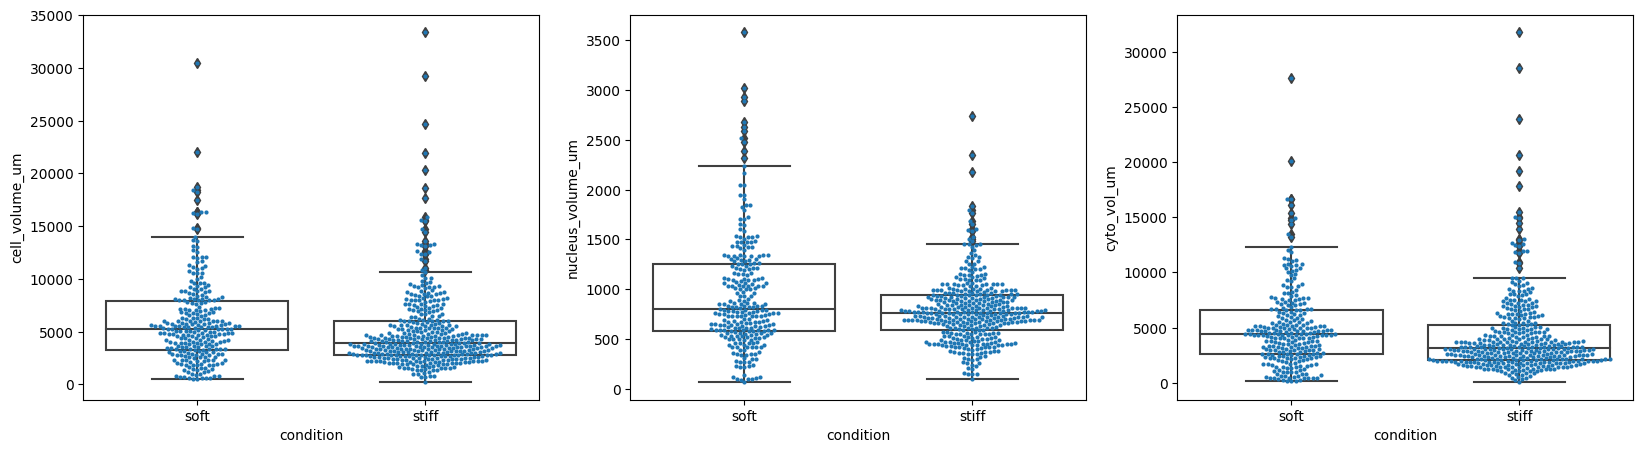

In [29]:
fig, ax = plt.subplots(ncols = 3, figsize = (20,5))
sns.swarmplot(data = all_mito_data, y="cell_volume_um", x = "condition", dodge=True, size = 3, ax=ax[0])
sns.boxplot(data = all_mito_data, y="cell_volume_um", x="condition",ax=ax[0], boxprops = {"facecolor":"None"})

sns.swarmplot(data = all_mito_data, y="nucleus_volume_um", x = "condition", dodge=True, size = 3, ax=ax[1])
sns.boxplot(data = all_mito_data, y="nucleus_volume_um", x="condition",ax=ax[1], boxprops = {"facecolor":"None"})

sns.swarmplot(data = all_mito_data, y="cyto_vol_um", x = "condition", dodge=True, size = 3, ax=ax[2])
sns.boxplot(data = all_mito_data, y="cyto_vol_um", x="condition",ax=ax[2], boxprops = {"facecolor":"None"})


Text(928.4459064327488, 0.5, 'Mito/Cell Volume')

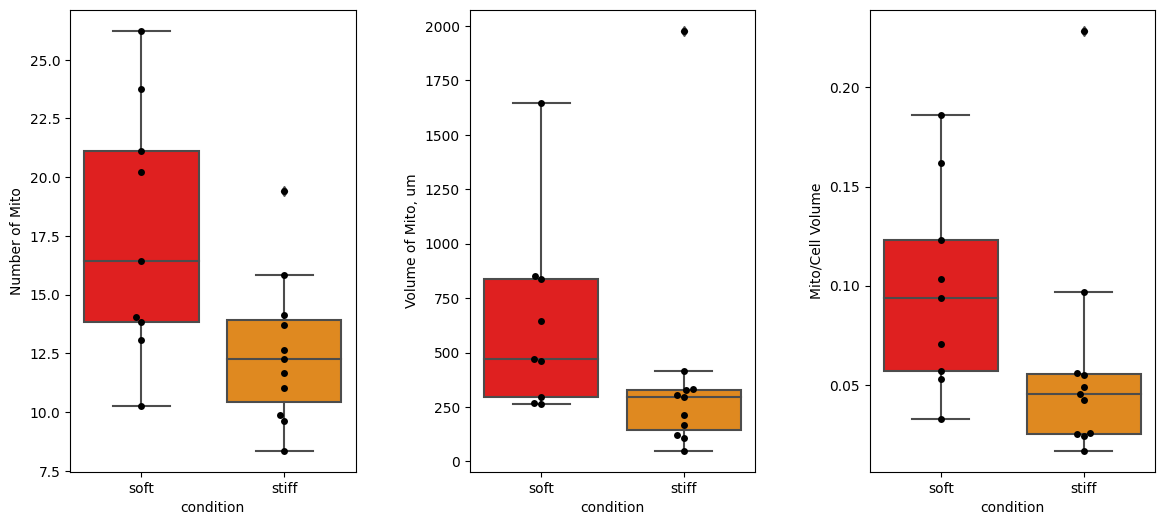

In [15]:
fig, ax = plt.subplots(figsize=(14,6), ncols=3,  gridspec_kw=dict(wspace=0.4))
sns.boxplot(data = average_no_mito,y="number_of_mito", x="condition"  ,dodge=True,  palette=mycol, ax=ax[0])
sns.swarmplot(data = average_no_mito,y="number_of_mito", x="condition" , ax=ax[0], color="k")

sns.boxplot(data = average_vol_mito,y="vol_of_mito_um", x="condition"  ,dodge=True,  palette=mycol, ax=ax[1])
sns.swarmplot(data = average_vol_mito,y="vol_of_mito_um", x="condition" , ax=ax[1], color="k")

sns.boxplot(data = average_mito_cell_vol,y="mito/cell_vol", x="condition"  ,dodge=True,  palette=mycol, ax=ax[2])
sns.swarmplot(data = average_mito_cell_vol,y="mito/cell_vol", x="condition" , ax=ax[2], color="k")

ax[0].set_ylabel("Number of Mito")
ax[1].set_ylabel("Volume of Mito, um")
ax[2].set_ylabel("Mito/Cell Volume")

([], [])

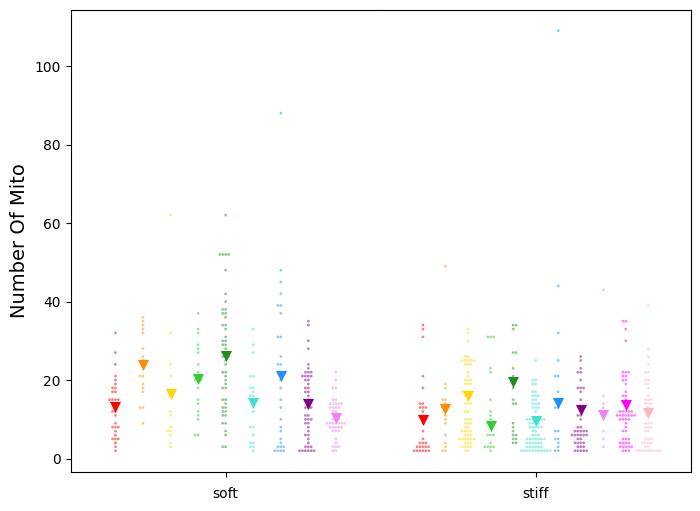

In [34]:
fig, ax = plt.subplots(figsize=(8,6), ncols=2, sharey=True, gridspec_kw=dict(wspace=0))
for i, condition in enumerate(["soft", "stiff"]):
    sns.swarmplot(data = all_mito_data[all_mito_data["condition"]==condition], y="number_of_mito", hue="image", alpha = 0.5, dodge=True, ax=ax[i], size=2, palette=mycol, legend=False)
    sns.swarmplot(data = average_no_mito[average_no_mito["condition"]==condition] ,y="number_of_mito", hue="image", alpha = 1, legend=False, dodge=True, ax=ax[i], marker="v", size=8, palette=mycol)
    ax[i].set_xlabel(condition)
for a in ax:
    a.set_ylabel (a.yaxis.get_label().get_text().replace("_", " ").title(), fontsize=14)
    #a.xaxis.label.set_visible(False)

ax[1].spines['left'].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[1].yaxis.set_visible(False)
ax[1].get_legend_handles_labels()

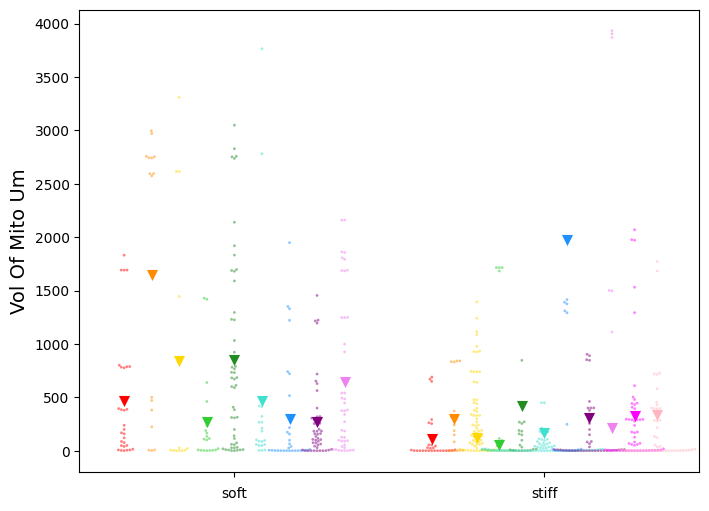

In [35]:
fig, ax = plt.subplots(figsize=(8,6), ncols=2, sharey=True, gridspec_kw=dict(wspace=0))
for i, condition in enumerate(["soft", "stiff"]):
    sns.swarmplot(data = all_mito_data[all_mito_data["condition"]==condition], y="vol_of_mito_um", hue="image", alpha = 0.5, legend=False, dodge=True, ax=ax[i], size=2, palette=mycol)
    sns.swarmplot(data = average_vol_mito[average_vol_mito["condition"]==condition] ,y="vol_of_mito_um", hue="image", alpha = 1, legend=False, dodge=True, ax=ax[i], marker="v", size=8, palette=mycol)
    ax[i].set_xlabel(condition)
for a in ax:
    a.set_ylabel (a.yaxis.get_label().get_text().replace("_", " ").title(), fontsize=14)
    #a.xaxis.label.set_visible(False)

ax[1].spines['left'].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[1].yaxis.set_visible(False)

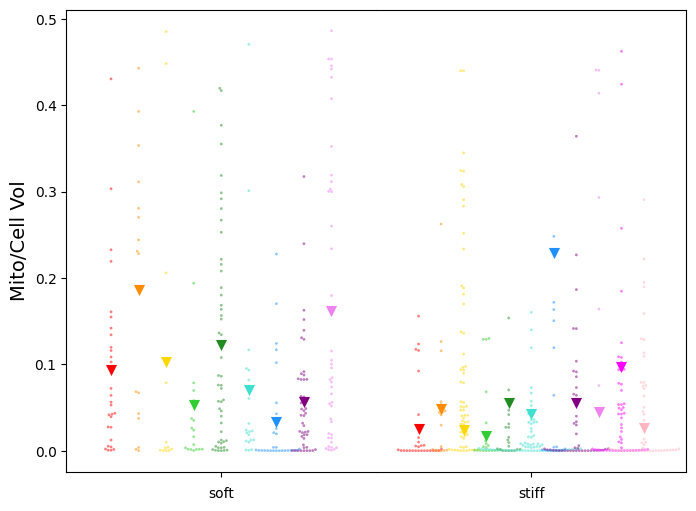

In [36]:
fig, ax = plt.subplots(figsize=(8,6), ncols=2, sharey=True, gridspec_kw=dict(wspace=0))
for i, condition in enumerate(["soft", "stiff"]):
    sns.swarmplot(data = all_mito_data[all_mito_data["condition"]==condition], y="mito/cell_vol", hue="image", alpha = 0.5, legend=False, dodge=True, ax=ax[i], size=2, palette=mycol)
    sns.swarmplot(data = average_mito_cell_vol[average_mito_cell_vol["condition"]==condition] ,y="mito/cell_vol", hue="image", alpha = 1, legend=False, dodge=True, ax=ax[i], marker="v", size=8, palette=mycol)
    ax[i].set_xlabel(condition)
for a in ax:
    a.set_ylabel (a.yaxis.get_label().get_text().replace("_", " ").title(), fontsize=14)
    #a.xaxis.label.set_visible(False)

ax[1].spines['left'].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[1].yaxis.set_visible(False)

In [17]:
single_entries = all_mito_data[~all_mito_data.image.duplicated()]

In [18]:
single_entries["mito/acinus_vol"] = single_entries["total_mito_volume_um"]/single_entries["total_acinus_volume"]
single_entries["cyto_vol"] = single_entries["total_acinus_volume"] - single_entries["total_nuclear_volume_um"]
single_entries["mito/cyto_vol"] = single_entries["total_mito_volume_um"]/single_entries["cyto_vol"]

In [19]:
single_entries.head()

,Unnamed: 0,nucleus_label,cell_label,nucleus/cell_volume,nucleus_volume_um,cell_volume_um,image,number_of_mito,vol_of_mito_um,total_acinus_volume,mito/cell_vol,total_nuclear_volume_um,total_mito_volume_um,number_of_cells,condition,mito/acinus_vol,cyto_vol,mito/cyto_vol
0,1,3,2,0.258632,1729.368816,6686.594257,10AmtHsp70soft106447a451ccafahrmtif,32,800.588648,392089.482741,0.119730,21043.168439,14098.925774,30,soft,0.035958,371046.314303,0.037998
30,0,1,1,0.151485,1830.111582,12081.150373,10AmtHsp70soft16447a451cc92fhrmtif,36,2756.847693,217202.376952,0.228194,19756.775785,26315.762539,16,soft,0.121158,197445.601167,0.133281
47,1,2,2,0.194942,3581.965015,18374.507166,10AmtHsp70soft26447a451ccd80hrmtif,24,1444.953007,163269.858820,0.078639,27286.202517,23361.128082,14,soft,0.143083,135983.656303,0.171794
60,0,1,1,0.169279,1347.519665,7960.333230,10AmtHsp70soft36447a451ccf61hrmtif,33,461.177996,182276.076665,0.057935,16661.588136,5040.934406,19,soft,0.027655,165614.488529,0.030438
79,0,1,1,0.109351,2044.542803,18696.981354,10AmtHsp70soft46447a451cd0f1hrmtif,62,600.563156,515747.480625,0.032121,72140.872736,43419.061469,51,soft,0.084187,443606.607888,0.097877


In [30]:
all_mito_data

,Unnamed: 0,nucleus_label,cell_label,nucleus/cell_volume,nucleus_volume_um,cell_volume_um,image,number_of_mito,vol_of_mito_um,total_acinus_volume,mito/cell_vol,total_nuclear_volume_um,total_mito_volume_um,number_of_cells,condition,cyto_vol_um
0,1,3,2,0.258632,1729.368816,6686.594257,10AmtHsp70soft106447a451ccafahrmtif,32,800.588648,392089.482741,0.119730,21043.168439,14098.925774,30,soft,4957.225441
1,3,5,4,0.239363,1846.464031,7714.073135,10AmtHsp70soft106447a451ccafahrmtif,18,1691.699782,392089.482741,0.219300,21043.168439,14098.925774,30,soft,5867.609104
2,5,9,8,0.216007,1035.849774,4795.453000,10AmtHsp70soft106447a451ccafahrmtif,15,493.006870,392089.482741,0.102807,21043.168439,14098.925774,30,soft,3759.603226
3,6,10,9,0.193159,1059.794432,5486.635977,10AmtHsp70soft106447a451ccafahrmtif,20,238.083870,392089.482741,0.043393,21043.168439,14098.925774,30,soft,4426.841546
4,11,15,14,0.179406,1034.487070,5766.184986,10AmtHsp70soft106447a451ccafahrmtif,27,158.463018,392089.482741,0.027481,21043.168439,14098.925774,30,soft,4731.697916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,63,88,80,0.088563,677.945281,7654.990179,10AmtHsp70stiff76447a451cebd3hrmtif,8,4.185448,406097.107342,0.000547,44234.931870,10557.744545,49,stiff,6977.044899
658,64,90,82,0.023715,145.127985,6119.709359,10AmtHsp70stiff76447a451cebd3hrmtif,9,215.891261,406097.107342,0.035278,44234.931870,10557.744545,49,stiff,5974.581374
659,65,91,83,0.182245,638.816206,3505.264242,10AmtHsp70stiff76447a451cebd3hrmtif,8,396.838896,406097.107342,0.113212,44234.931870,10557.744545,49,stiff,2866.448036
660,66,92,84,0.122316,253.365623,2071.407540,10AmtHsp70stiff76447a451cebd3hrmtif,4,4.282784,406097.107342,0.002068,44234.931870,10557.744545,49,stiff,1818.041917


Text(0.5, 36.72222222222221, 'Number of Mito')

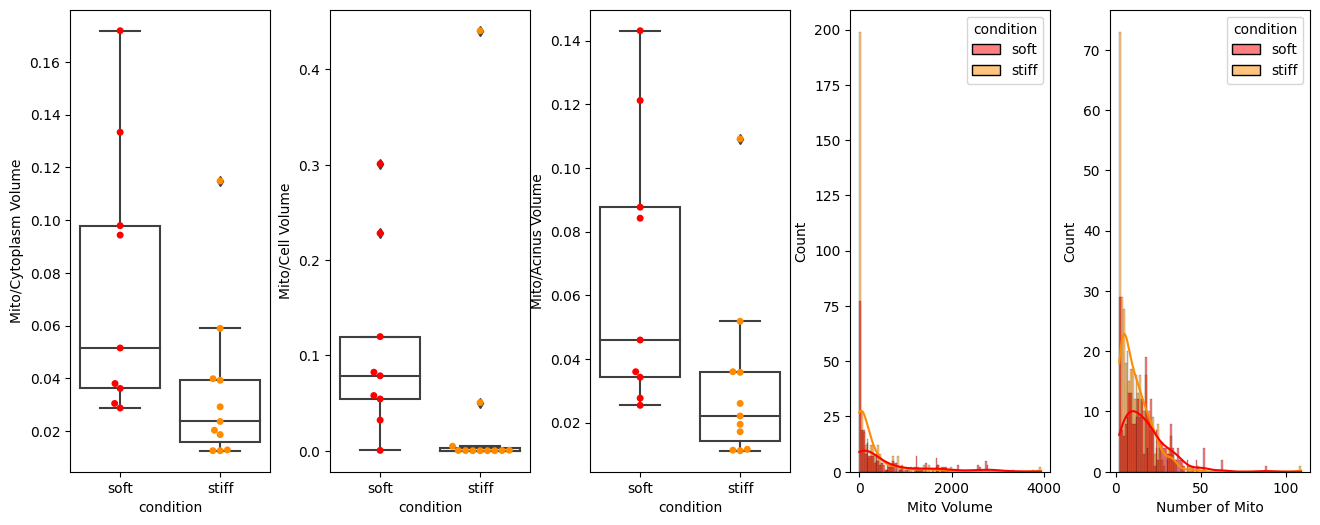

In [22]:
fig, ax = plt.subplots(figsize=(16,6), ncols = 5, gridspec_kw=dict(wspace=0.3))
sns.swarmplot(data = single_entries, y="mito/cyto_vol", x="condition",ax=ax[0], palette=mycol)
sns.boxplot(data = single_entries, y="mito/cyto_vol", x="condition",ax=ax[0], boxprops = {"facecolor":"None"})
ax[0].set_ylabel("Mito/Cytoplasm Volume")

sns.swarmplot(data = single_entries, y="mito/cell_vol", x="condition",ax=ax[1], palette=mycol)
sns.boxplot(data = single_entries, y="mito/cell_vol", x="condition",ax=ax[1], boxprops = {"facecolor":"None"})
ax[1].set_ylabel("Mito/Cell Volume")


sns.swarmplot(data = single_entries, y="mito/acinus_vol", x="condition",ax=ax[2], palette=mycol)
sns.boxplot(data = single_entries, y="mito/acinus_vol", x="condition",ax=ax[2], boxprops = {"facecolor":"None"})
ax[2].set_ylabel("Mito/Acinus Volume")

sns.histplot(data = all_mito_data, x="vol_of_mito_um", hue="condition", bins=100, kde="True", ax=ax[3], palette=mycol)
ax[3].set_xlabel("Mito Volume")

sns.histplot(data = all_mito_data, x="number_of_mito", hue="condition", bins=100, kde="True", ax=ax[4], palette=mycol)
ax[4].set_xlabel("Number of Mito")

 # Explanation

In [51]:
image_root = "E:\\MCF10A_tifs\\Stiff" 
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
membrane_root ="E:\\MCF10A_tifs\\Stiff_Binarised_Membrane"
membrane_mask_paths = list(pathlib.Path(membrane_root).glob("**/*.tif"))
nuclei_root ="E:\\MCF10A_tifs\\Stiff_Binarised_Nuclear"
nuclei_mask_paths = list(pathlib.Path(nuclei_root).glob("**/*.tif"))

image_no = 10
stiffness = "soft"
membrane_mask = imread(membrane_mask_paths[image_no])
nuclei_mask = imread(nuclei_mask_paths[image_no])
original_image = imread(image_paths[image_no])
original_image =np.clip(original_image, a_min = 0, a_max = 255)
original_spacing = pixel_size(image_paths[image_no])
scale_change = original_spacing[2] / original_spacing[0]
new_pixel_size = 4 * original_spacing[0]
print(scale_change)

mito = original_image[:,1,:,:]
thresh = threshold_otsu(mito) # apply an otsu threshold to the image
mito = mito > thresh
mito = remove_small_objects(mito, min_size=10)
mito_labels = label(mito).astype(np.uint16)

rescaled_mito = rescale(scale = (0.25*scale_change, 0.25,0.25), image=original_image[:,1,:,:], anti_aliasing = False)
rescaled_caax = rescale(scale = (0.25*scale_change, 0.25,0.25), image=original_image[:,2,:,:], anti_aliasing = False)
rescaled_dapi = rescale(scale = (0.25*scale_change, 0.25,0.25), image=original_image[:,0,:,:], anti_aliasing = False)
rescaled_membrane_mask = rescale(scale = (0.25*scale_change, 0.25,0.25), image=membrane_mask, anti_aliasing = False)
rescaled_dapi_mask = rescale(scale = (0.25*scale_change, 0.25,0.25), image=nuclei_mask, anti_aliasing = False)
mito_labels = rescale(scale = (0.25*scale_change, 0.25,0.25), image=mito_labels, anti_aliasing = False, preserve_range=True, order=0)

rescaled_acinus = rescaled_caax + rescaled_dapi
#rescaled_acinus = np.clip(rescaled_caax, a_min =0, a_max=256) + 5*(gaussian(np.clip(rescaled_dapi, a_min =0, a_max=256), sigma=5))
clipped = rescaled_acinus.clip(min =np.quantile(rescaled_acinus, 0.2), max = np.quantile(rescaled_acinus, 0.8))
acinus_smoothed = gaussian(clipped, sigma = 0.5)
thresh = threshold_otsu(acinus_smoothed)

binary = acinus_smoothed > thresh
binary = remove_small_holes(binary, area_threshold = 1000000)
binary = remove_small_objects(binary, min_size = 100000)
binary = closing(binary, ball(3))
# Label images and flag any issues
whole_acinus = label(binary)
table = regionprops_table(whole_acinus, properties=('label', 'area'),)
condition = (table['area'] >= table['area'].max())
# Filter the labels so we only keep the largest one
input_labels = table['label']
output_labels = input_labels * condition
largest_acinus_label = util.map_array(whole_acinus, input_labels, output_labels)
# TIDY MEMBRANE
membrane = gaussian(rescaled_membrane_mask, sigma = 1) 
thresh = threshold_otsu(rescaled_membrane_mask)
membrane = membrane > thresh
new_membrane = thin(membrane[0,:,:])
for i in range(1, membrane.shape[0]):
    thinned = thin(membrane[i,:,:])
    new_membrane = np.dstack((new_membrane, thinned))
new_membrane = np.rollaxis(new_membrane, 2,0)
processed_membrane = gaussian(new_membrane, sigma = 1)
thresh = threshold_otsu(processed_membrane)
processed_membrane = processed_membrane> thresh
# SEGMENT NUCLEI
watershed_dapi = perform_watershed_and_filter_volumes(rescaled_dapi_mask, new_pixel_size, seed_point_diamter_um = 5, seed = "none").astype(np.uint16)
# SEGMENT MEMBRANE BASED ON NUCLEI POSITIONS
watershed_membrane = perform_watershed_and_filter_volumes(util.invert(processed_membrane), new_pixel_size, seed_point_diamter_um = 5, seed = watershed_dapi)
watershed_membrane_expanded = expand_labels(watershed_membrane, distance = 8)
matching_nuc_and_cell = find_matching_properties(watershed_dapi, watershed_membrane_expanded, new_pixel_size, image_paths[image_no]) ##########################CHANGE

#########ANALYSIS
table = pd.DataFrame(regionprops_table(watershed_membrane_expanded, properties=('label', 'area'),))
mito_props_table = pd.DataFrame(regionprops_table(mito_labels,properties=('label', 'area')))
nuclei_props_table = pd.DataFrame(regionprops_table(watershed_dapi,properties=('label', 'area')))
acinus_props_table = pd.DataFrame(regionprops_table(largest_acinus_label,properties=('label', 'area')))


6.078260756292821


In [52]:
available_cell_indices = [i for i in matching_nuc_and_cell["cell_label"].unique()]

cell_index = available_cell_indices[10]
nuc_index = int(matching_nuc_and_cell.loc[matching_nuc_and_cell['cell_label'] == cell_index]["nucleus_label"])


mito_in_region = np.unique(mito_labels * (watershed_dapi == nuc_index))
number_of_mito = len(mito_in_region)
total_mito_vol = mito_props_table[mito_props_table["label"].isin(mito_in_region)]["area"].sum()* new_pixel_size**3

# ####MITO INTENSITY WITH DISTANCE
nuc_of_interest = watershed_dapi * (watershed_dapi == nuc_index) > threshold_otsu(watershed_dapi * (watershed_dapi == nuc_index))

# nuc_of_interest = watershed_dapi * (watershed_dapi == 10)
# cell_of_interest = watershed_membrane_expanded * (watershed_membrane_expanded == 10)
cell_of_interest = watershed_membrane_expanded * (watershed_membrane_expanded == cell_index) > threshold_otsu(watershed_membrane_expanded * (watershed_membrane_expanded == cell_index))


distance = ((distance_transform_edt(1- (nuc_of_interest))) * cell_of_interest) * (new_pixel_size*new_pixel_size)
mito_in_cell = cell_of_interest * (mito_labels > 1)




In [53]:
viewer = napari.Viewer()

viewer.add_labels(cell_of_interest, name="Cell")
viewer.add_labels(nuc_of_interest, name="Nuc")

viewer.add_image(distance)
viewer.add_image(mito_in_cell)


<Image layer 'mito_in_cell' at 0x1ade4e3b730>

In [73]:
all_distance_df = pd.read_csv('TOMTEST.csv').drop('Unnamed: 0', axis=1)

all_distance_df['max_distance'] = all_distance_df\
    .groupby(['Image', 'Cell Label'])\
        .Distance\
            .transform('max')

all_distance_df['Distance'] = all_distance_df.Distance / all_distance_df.max_distance
all_distance_df.drop('max_distance', axis=1, inplace=True)
all_distance_df.Distance = round(all_distance_df.Distance, 2)

In [74]:
all_distance_df = all_distance_df\
    .groupby(['Image', 'Condition', 'Cell Label', 'Distance'], as_index=False)\
        .Count\
            .sum()

In [70]:
all_distance_df['Density'] = all_distance_df.Count / all_distance_df.Distance**2

### Distance Analysis

In [41]:
excluded_keys = excluded_mito_data["image"]+ " " + excluded_mito_data["cell_label"].astype(str)
excluded_keys


46      10AmtHsp70soft26447a451ccd80hrmtif 1
49      10AmtHsp70soft26447a451ccd80hrmtif 4
509    10AmtHsp70stiff36447a451ce4d1hrmtif 6
dtype: object

In [65]:
data = [pd.read_parquet("C:\\Users\\isobe\\Dropbox (The University of Manchester)\\Python\Data_For_Others\\Fabianna\\Analysis\\Distances\\" + x) for x in os.listdir('C:\\Users\\isobe\\Dropbox (The University of Manchester)\\Python\Data_For_Others\\Fabianna\\Analysis\\Distances\\')]
data = pd.concat(data)
data["keys"] = data["Image"]+ " " + data["Cell Label"].astype(str)
data = data[~data["keys"].isin(excluded_keys)]

In [67]:
data['max_distance'] = data.groupby(['Image', 'Cell Label']).Rounded_Distance.transform('max')
data.Rounded_Distance = data.Rounded_Distance / data.max_distance
data.drop('max_distance', axis=1, inplace=True)

In [69]:
data.Rounded_Distance = data.Rounded_Distance.apply(lambda x: round(x, 2))


In [71]:
data = data.groupby(['Condition', 'Rounded_Distance'], as_index=False)[['sum', 'count']].sum()

In [73]:
data['ratio'] = data['sum'] / data['count']

Text(0, 0.5, 'Number of Pixels Occupied By Mitochondria')

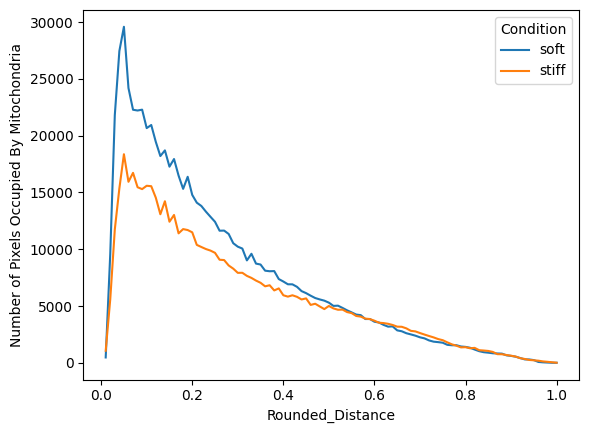

In [78]:
fig, ax = plt.subplots()
pd.pivot_table(data[data["Rounded_Distance"]!= 0], index='Rounded_Distance', values='sum', columns='Condition').plot(ax=ax)
ax.set_ylabel('Number of Pixels Occupied By Mitochondria')

Text(0, 0.5, 'Ratio of Pixels Occupied By Mitochondria')

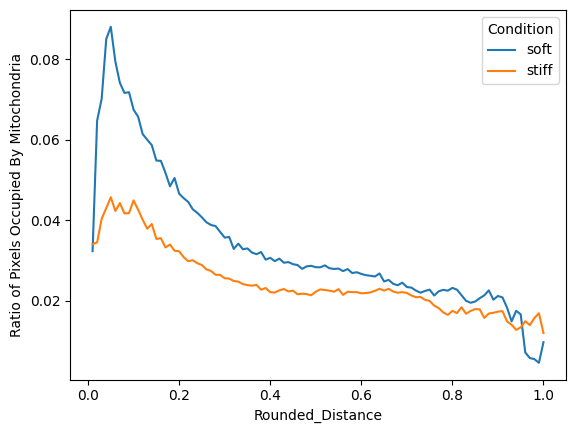

In [79]:
fig, ax = plt.subplots()
pd.pivot_table(data[data["Rounded_Distance"]!= 0], index='Rounded_Distance', values='ratio', columns='Condition').plot(ax=ax)
ax.set_ylabel('Ratio of Pixels Occupied By Mitochondria')

# Volume of all Mito

In [68]:
def volume_of_mito(image_no, stiffness):

    # membrane_mask = imread(membrane_mask_paths[image_no])
    # nuclei_mask = imread(nuclei_mask_paths[image_no])
    original_image = imread(image_paths[image_no])
    original_image =np.clip(original_image, a_min = 0, a_max = 255)
    original_spacing = pixel_size(image_paths[image_no])
    scale_change = original_spacing[2] / original_spacing[0]
    new_pixel_size = 4 * original_spacing[0]
    # print(scale_change)

    mito = original_image[:,1,:,:]
    thresh = threshold_otsu(mito) # apply an otsu threshold to the image
    mito = mito > thresh
    mito = remove_small_objects(mito, min_size=10)
    mito_labels = label(mito).astype(np.uint16)

    rescaled_mito = rescale(scale = (0.25*scale_change, 0.25,0.25), image=original_image[:,1,:,:], anti_aliasing = False)
    mito_labels = rescale(scale = (0.25*scale_change, 0.25,0.25), image=mito_labels, anti_aliasing = False, preserve_range=True, order=0)

    mito_props_table = pd.DataFrame(regionprops_table(mito_labels,properties=('label', 'area')))
    mito_props_table["Volume_um"] = mito_props_table["area"]* new_pixel_size**3
    mito_props_table.rename(columns={"area": "Volume_pixels"})
    mito_props_table["condition"] = stiffness
    mito_props_table["image_no"] = image_no
    mito_props_table.drop(labels="label", axis = 1)
    mito_props_table.to_csv("E:\\FABIANNA\\mito_volumes_{}_i_{}.csv".format(stiffness, image_no))


In [69]:
image_root = "E:\\MCF10A_tifs\\Soft" 
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
image_paths.sort()
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    Parallel(n_jobs=3)(delayed(volume_of_mito)(i, "soft") for i in range(len(image_paths)))


Image Analysis: 100%|██████████| 9/9 [00:16<00:00,  1.79s/it]


In [70]:
image_root = "E:\\MCF10A_tifs\\Stiff" 
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
image_paths.sort()
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    Parallel(n_jobs=3)(delayed(volume_of_mito)(i, "stiff") for i in range(len(image_paths)))


Image Analysis: 100%|██████████| 12/12 [00:18<00:00,  1.54s/it]


In [71]:
csv_root = "E:\\FABIANNA\\"
csvs = list(pathlib.Path(csv_root).glob("**/*.csv"))
all_mito_vol_data = []
for csv in csvs:
    mito_data = pd.read_csv(csv)
    #mito_data["type"] = str(os.path.basename(csv)).split("_")[2]
    all_mito_vol_data.append(mito_data)

all_mito_data_original = pd.concat(all_mito_vol_data)

In [72]:
all_mito_data_original.to_csv("Mito_vols_only.csv")

In [17]:
mito_vols = pd.read_csv("Mito_vols_only.csv")

In [7]:
mito_vols = mito_vols[mito_vols["Volume_um"] < 100]

<Axes: xlabel='condition', ylabel='Volume_um'>

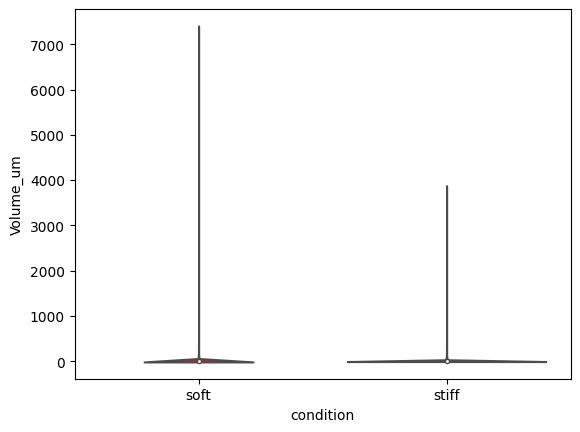

In [18]:
sns.violinplot(data = mito_vols, y="Volume_um", x="condition", dodge="True", palette=mycol)

<Axes: xlabel='condition', ylabel='Volume_um'>

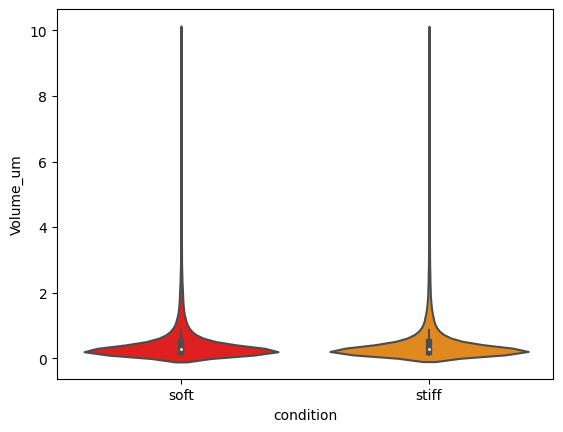

In [13]:
mito_vols = mito_vols[mito_vols["Volume_um"] < 10]
sns.violinplot(data = mito_vols, y="Volume_um", x="condition", dodge="True", palette=mycol)

<Axes: xlabel='Volume_um', ylabel='Count'>

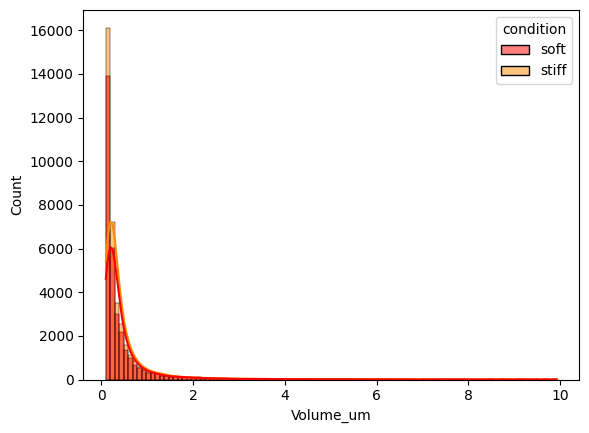

In [15]:
sns.histplot(data = mito_vols, x="Volume_um", hue="condition", bins=100, kde="True", palette=mycol)

<Axes: xlabel='Volume_um', ylabel='Count'>

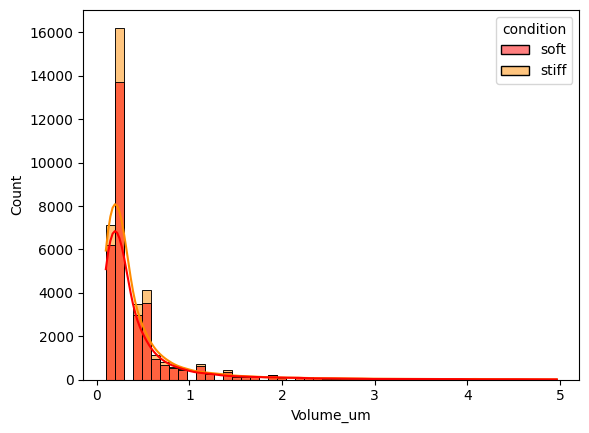

In [21]:
mito_vols = mito_vols[mito_vols["Volume_um"] < 5]
fig, ax = plt.subplots()
sns.histplot(data = mito_vols, x="Volume_um", hue="condition", bins=50, kde="True", palette=mycol)
